In [3]:
#logistic regression for the diabaetes dataset
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [4]:
#Load and prepare the data
df=pd.read_csv("diabetes.csv")
X=df.drop("Outcome",axis=1)
y=df['Outcome']

In [5]:
#Train test and split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=101,stratify=y)
print(f"Training samples:{len(X_train)}")
print(f"Testing samples:{len(X_test)}")

Training samples:614
Testing samples:154


In [7]:
#Standardize insulin (fit on train, transform both)
scaler=StandardScaler()
X_train['Insulin']=scaler.fit_transform(X_train[['Insulin']])
X_test['Insulin']=scaler.transform(X_test[['Insulin']])

In [8]:
#Train full model(all features)
model=LogisticRegression(max_iter=500)
model.fit(X_train,y_train)

LogisticRegression(max_iter=500)

In [9]:
#Evalution onTEST set
y_pred=model.predict(X_test)

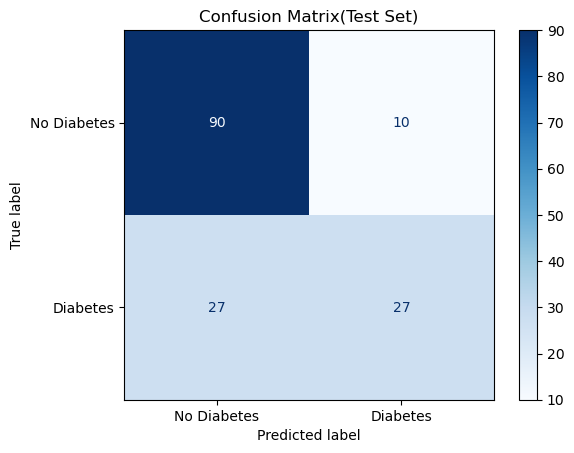

In [10]:
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No Diabetes","Diabetes"]).plot(cmap='Blues')
plt.title("Confusion Matrix(Test Set)")
plt.show()

In [12]:
print("\n===Test Set Performance===")
print("\n Classification Report:\n")
print(classification_report(y_test,y_pred))


===Test Set Performance===

 Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       100
           1       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154



In [13]:
#6.Logistic Regression Curve(Glucose only-for visualization)
#Extract Glucose from train/test sets
X_train_glucose=X_train[["Glucose"]].copy()
X_test_glucose=X_test[["Glucose"]].copy()

In [14]:
#Train seperate single feature model for Visualization
model_glucose=LogisticRegression(max_iter=500)
model_glucose.fit(X_train_glucose,y_train)

LogisticRegression(max_iter=500)

In [15]:
#Create Smooth Curve
glucose_min=df['Glucose'].min()
glucose_max=df['Glucose'].max()
glucose_values=np.linspace(glucose_min,glucose_max,200).reshape(-1,1)
y_curve=model_glucose.predict_proba(glucose_values)[:,1]


C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


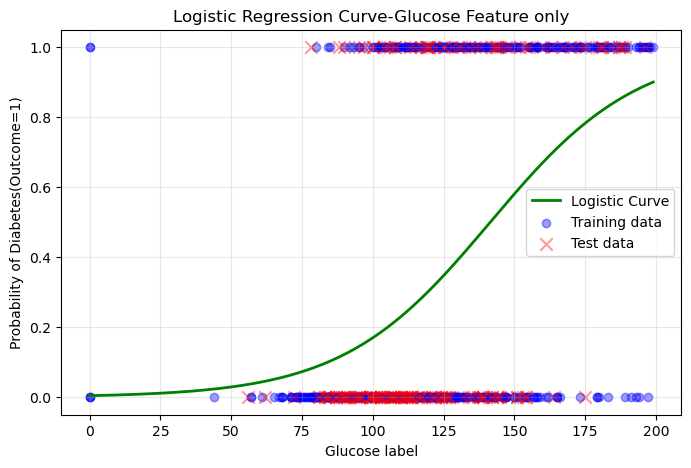

In [16]:
#Plot sigmaoid curve with train/test split visulization
plt.figure(figsize=(8,5))
plt.plot(glucose_values,y_curve,color='green',linewidth=2,label="Logistic Curve")
plt.scatter(X_train_glucose,y_train,color='blue',alpha=0.4,label="Training data")
plt.scatter(X_test_glucose,y_test,color='red',alpha=0.4,marker='x',s=80,label="Test data")
plt.xlabel("Glucose label")
plt.ylabel("Probability of Diabetes(Outcome=1)")
plt.title("Logistic Regression Curve-Glucose Feature only")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()